# 9 &middot; Weak Gravitational Lensing

Weak lensing distorts the images of distant galaxies as their light passes foreground matter.
The **convergence** $\kappa$ measures the projected mass along the line of sight (weighted by a
lensing efficiency kernel), and the **shear** $\gamma=(\gamma_1,\gamma_2)$ is the
ellipticity distortion derived from it.

This notebook turns a spherical PM lightcone (built as in [notebook 8](08-Advanced-PM.ipynb)) into:

1. **convergence** maps via two methods &mdash;

   | Method | Function | JAX | Accuracy |
   |--------|----------|-----|----------|
   | Born approximation | `jfli.born` | yes (differentiable) | first order |
   | Ray-tracing | `jfli.raytrace` | no (dorian, post-Born) | full distortion matrix |

2. **shear** maps via spherical Kaiser-Squires (`kappa.get_shear()`), and
3. **catalogs**: saving convergence and shear to Parquet for later analysis (e.g.
   [notebook 10](10-External-Catalog.ipynb)).

This notebook runs **distributed across a device mesh** (8 CPU devices in this demo): a single
`field_sharding` argument on `gaussian_initial_conditions` partitions the initial field, and every
downstream operation (`lpt`, `nbody`, lightcone painting) respects it automatically &mdash; exactly
as in [notebook 5](../1-introduction-and-basics/05-Distributed-PM.ipynb). The lensing pipeline code
below is identical to the single-device case; see
[notebook 4 &middot; SPMD Basics](../1-introduction-and-basics/04-SPMD-Basics.md) for the M / N
sharding convention this notebook follows.

## Setup

You can simulate multiple devices on a single CPU by setting the `XLA_FLAGS` environment variable to include `--xla_force_host_platform_device_count=8` (or however many devices you want). This forces JAX to treat the CPU as if it had multiple devices, allowing you to test distributed computations without needing actual GPUs.

The `--xla_force_host_platform_device_count` flag must be set **before** JAX initialises its backend (before the first `import jax`).

```
import os
os.environ["XLA_FLAGS"] = "--xla_force_host_platform_device_count=8"
os.environ["JAX_PLATFORMS"] = "cpu"
```

On real GPUs, drop both variables &mdash; JAX discovers the devices automatically.

In [1]:
import logging

import jax
import jax.numpy as jnp
import jax_cosmo as jc
import matplotlib.pyplot as plt
import numpy as np
from jax.sharding import AxisType, NamedSharding
from jax.sharding import PartitionSpec as P

import jax_fli as jfli

jax.config.update("jax_enable_x64", False)
print(f"Number of devices: {jax.device_count()}")
print(jax.devices())

/lustre/fswork/projects/rech/tkc/commun/venv/pm/lib/python3.12/site-packages/jaxlib/plugin_support.py:91: RuntimeWarning: JAX plugin jax_cuda12_plugin version 0.10.1 is installed, but it is not compatible with the installed jaxlib version 0.10.0, so it will not be used.
  warnings.warn(


JAX is not using 64-bit precision. This will dramatically affect numerical precision at even moderate L.


JAX is not using 64-bit precision. Results will diverge from healpy even at moderate nside and can overflow for nside > 8192. See the README on numerical precision.


Number of devices: 8
[CudaDevice(id=0), CudaDevice(id=1), CudaDevice(id=2), CudaDevice(id=3), CudaDevice(id=4), CudaDevice(id=5), CudaDevice(id=6), CudaDevice(id=7)]


## Device mesh and sharding

A `Mesh` maps physical devices onto named axes; a `PartitionSpec` then says which array
dimensions are split over which mesh axes. The `jaxpm` distributed backend expects a **2-D mesh** so that the first two spatial dimensions of the 3-D field are each partitioned.

For **lensing** we shape the mesh as `(N // n_bins, n_bins)`: the `x` axis carries the pixels (and the 3-D spatial decomposition), while the `y` axis carries the `n_bins` tomographic source bins. This lets `get_shear` distribute the per-bin Kaiser–Squires transform across devices (see *Sharding the shear* below). A pure density / N-body run instead uses an `(N, 1)` mesh to maximize the spatial partitioning — see [05-Distributed-PM](../1-introduction-and-basics/05-Distributed-PM.ipynb).

In [2]:
# Lensing-oriented mesh: `x` carries npix/space, `y` carries the n_bins tomographic source bins.
# (N // n_bins, n_bins) trades some npix sharding to distribute the per-bin Kaiser-Squires
# (get_shear) across devices. A pure density sim is more efficient on (N, 1) -- see 05-Distributed-PM.
n_bins = 2
mesh = jax.make_mesh((jax.device_count() // n_bins, n_bins), ("x", "y"), axis_types=(AxisType.Auto, AxisType.Auto))
sharding = NamedSharding(mesh, P("x", "y"))
print(f"Mesh shape     : {mesh.shape}")
print(f"Partition spec : {sharding.spec}")

Mesh shape     : OrderedDict({'x': 4, 'y': 2})
Partition spec : P('x', 'y')


## A spherical lightcone

We build an 8-shell HEALPix lightcone with the `OnionTiler` kernel (`drift_on_lightcone=True`
so particles are drifted onto the lightcone for lensing). Passing `field_sharding` (and a
`halo_size` of ghost cells for the stencil/FFT exchange) to `gaussian_initial_conditions` is the
only distributed-specific change &mdash; the returned field carries the sharding, so `lpt` and
`nbody` run partitioned across the mesh with no further edits.

In [3]:
key = jax.random.PRNGKey(0)
cosmo = jc.Planck18()

# --- Resolution -------------------------------------------------------------------------------
mesh_size = (128, 128, 128)
nside = 128
halo_size = (8, 8)
nb_shells = 8

box_size = jfli.compute_box_size_from_redshift(cosmo, 1.0, observer_position=(0.5, 0.5, 0.5))
box_size = tuple(float(b) for b in box_size)

initial_field = jfli.gaussian_initial_conditions(
    key,
    mesh_size,
    box_size,
    cosmo=cosmo,
    nside=nside,
    field_sharding=sharding,
    halo_size=halo_size,
)
print(f"initial field shape    : {initial_field.array.shape}")
print(f"initial field sharding : {initial_field.array.sharding}")

dx, p = jfli.lpt(cosmo, initial_field, ts=0.001, order=1)
solver = jfli.BullFrog(
    interp_kernel=jfli.NoInterp(painting=jfli.PaintingOptions(target="spherical", scheme="ngp")),
    t0=0.001,
    t1=1.0,
    n_steps=16,
)
lightcone = jfli.nbody(cosmo, dx, p, nb_shells=nb_shells, solver=solver).block_until_ready()
print(f"lightcone: {lightcone.shape}, scale factors: {np.asarray(lightcone.scale_factors).round(2)}")

initial field shape    : (256, 256, 256)
initial field sharding : NamedSharding(mesh=Mesh('x': 4, 'y': 2, axis_types=(Auto, Auto)), spec=P('x', 'y'), memory_kind=device)


lightcone: (8, 3145728), scale factors: [0.97 0.91 0.84 0.78 0.72 0.66 0.59 0.53]


### Inspecting the field sharding

The simulation runs **distributed** across the device mesh, and every field carries its layout. The
3-D fields keep the **volumetric** layout &mdash; the LPT displacement `dx` is `P("x", "y")` (the
first two spatial axes split over the mesh, the third replicated). The painted **spherical
lightcone** is 1-D in pixels per shell, so it trims to `P(None, "x")`: the HEALPix pixels are sharded
over the `x` (M) axis and the shell axis is replicated. See
[04 &middot; SPMD Basics](../1-introduction-and-basics/04-SPMD-Basics.md) for the full M / N
convention.

In [4]:
print(f"Sharding of LPT displacement field dx: {dx.array.sharding}")
jax.debug.visualize_array_sharding(dx.array[..., 0, 0])
print(f"Sharding of lightcone: {lightcone.array.sharding}")
jax.debug.visualize_array_sharding(lightcone.array)

Sharding of LPT displacement field dx: NamedSharding(mesh=Mesh('x': 4, 'y': 2, axis_types=(Auto, Auto)), spec=P('x', 'y'), memory_kind=device)


                        
   GPU 0       GPU 1    
                        
                        
   GPU 2       GPU 3    
                        
                        
   GPU 4       GPU 5    
                        
                        
   GPU 6       GPU 7    
                        

Sharding of lightcone: NamedSharding(mesh=Mesh('x': 4, 'y': 2, axis_types=(Auto, Auto)), spec=P(None, 'x'), memory_kind=device)


## Source redshift distributions $n(z)$

Lensing is computed for a galaxy population with a redshift distribution $n(z)$. We use four
tomographic bins from a Stage-3 forecast (`jfli.io.get_stage3_nz_shear`).

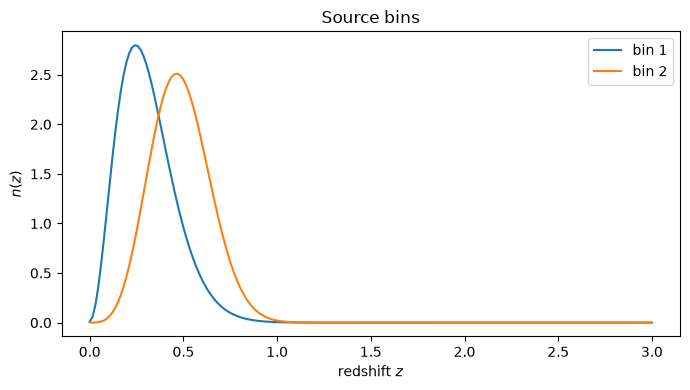

In [5]:
nz_sources = jfli.io.get_stage3_nz_shear()[:n_bins]

z = jnp.linspace(0.0, 3.0, 200)
plt.figure(figsize=(7, 4))
for i, nz in enumerate(nz_sources):
    plt.plot(z, nz(z), label=f"bin {i + 1}")
plt.xlabel("redshift $z$")
plt.ylabel("$n(z)$")
plt.legend()
plt.title("Source bins")
plt.tight_layout()
plt.show()

## Born approximation

`jfli.born` integrates the weighted projected density along straight (unperturbed) light paths.
It is fully JAX — `jit`/`grad`-able — and returns a `SphericalKappaField` (one map per source
bin).

SphericalKappaField  shape=(2, 3145728)


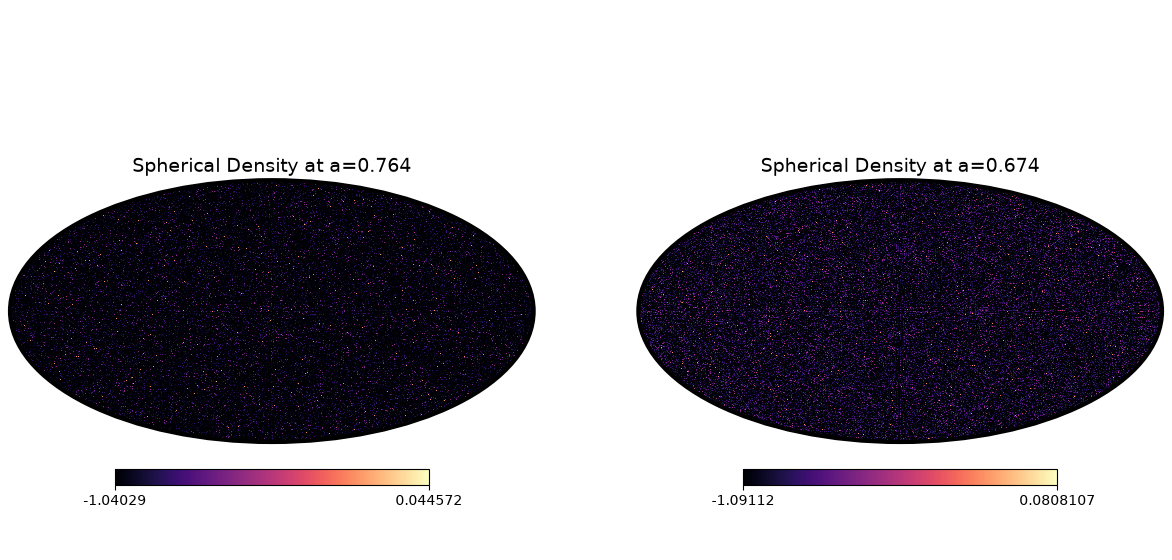

In [6]:
kappa_born = jfli.born(cosmo, lightcone, nz_shear=nz_sources)
print(f"{type(kappa_born).__name__}  shape={kappa_born.shape}")
kappa_born.apply_fn(lambda x: jnp.log10(x + 0.1)).show(ncols=3)

## Inspecting the convergence sharding

`born` returns the convergence already in the **lensing layout** `P("y", "x")`: the `n_bins`
tomographic maps split over the `y` (N) axis and the HEALPix pixels over `x` (M) &mdash; the
*transpose* of the volumetric layout above, so each device holds whole pixels for a subset of bins
(ready for the per-bin Kaiser&ndash;Squires below). `field_sharding` itself stays the canonical
`P("x", "y")`; only the array carries the transposed layout.

In [7]:
print(f"Sharding of convergence κ (born): {kappa_born.array.sharding}")
jax.debug.visualize_array_sharding(kappa_born.array)

Sharding of convergence κ (born): NamedSharding(mesh=Mesh('x': 4, 'y': 2, axis_types=(Auto, Auto)), spec=P('y', 'x'), memory_kind=device)


## Convergence &rarr; shear (Kaiser-Squires)

`SphericalKappaField.get_shear()` applies the spherical Kaiser-Squires relation, converting each
$\kappa$ map into a pure-E-mode shear field $(\gamma_1, \gamma_2)$ — a `SphericalShearField` of
shape `(n_bins, 2, npix)`.

### Sharding the shear

The spherical Kaiser–Squires transform (`map2alm`/`alm2map`) is **not partition-aware on `npix`**,
so `get_shear` cannot transform a convergence whose pixels are split across devices in place. It
runs each bin's transform inside a `shard_map` and **mirrors the convergence sharding onto the
shear**: convergence `P(b, x)` → shear `P(b, None, x)` (`b` = bins axis, `x` = npix axis). Three
cases:

| convergence sharding | what happens | shear sharding |
|---|---|---|
| `P("y", "x")` — bins on `y`, npix on `x` | each bin's SHT runs on its own device(s) — **distributed over bins** | `P("y", None, "x")` |
| `P(None, "x")` — only npix sharded | the SHT is **replicated** across devices (a warning is emitted), but the shear stays npix-sharded | `P(None, None, "x")` |
| single device / `(N, 1)` mesh | plain transform | unsharded |

To distribute over bins we put the `n_bins` maps on the `y` axis (`P("y", "x")`), which needs the
`y`-axis size to divide `n_bins` — exactly the `(N // n_bins, n_bins)` mesh chosen above. `born`
returns an npix-sharded convergence, so we reshard it onto `(y, x)` first.

[get_shear] 0 convergence                      shape=(2, 3145728) sharding=P('y', 'x')
[get_shear] 1 bins-sharded  P(N, None)         shape=(2, 3145728) sharding=P('y', None)
[get_shear] (inside shard_map) per-device block = (1, 3145728) (maps, npix)


E0616 11:27:42.842370 2287915 slow_operation_alarm.cc:73] 
********************************
[Compiling module jit__unnamed_function for GPU] Very slow compile? If you want to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.
********************************


E0616 11:28:35.895302 2287643 slow_operation_alarm.cc:140] The operation took 2m53.054053939s

********************************
[Compiling module jit__unnamed_function for GPU] Very slow compile? If you want to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.
********************************


[get_shear] 2 shard_map out P(N, None, None)   shape=(2, 2, 3145728) sharding=P('y', None, None)


[get_shear] 3 final         P([None,] N, None, M) shape=(2, 2, 3145728) sharding=P('y', None, 'x')
SphericalShearField  shape=(2, 2, 3145728)  (bins, [g1,g2], npix)
shear sharding : P('y', None, 'x')


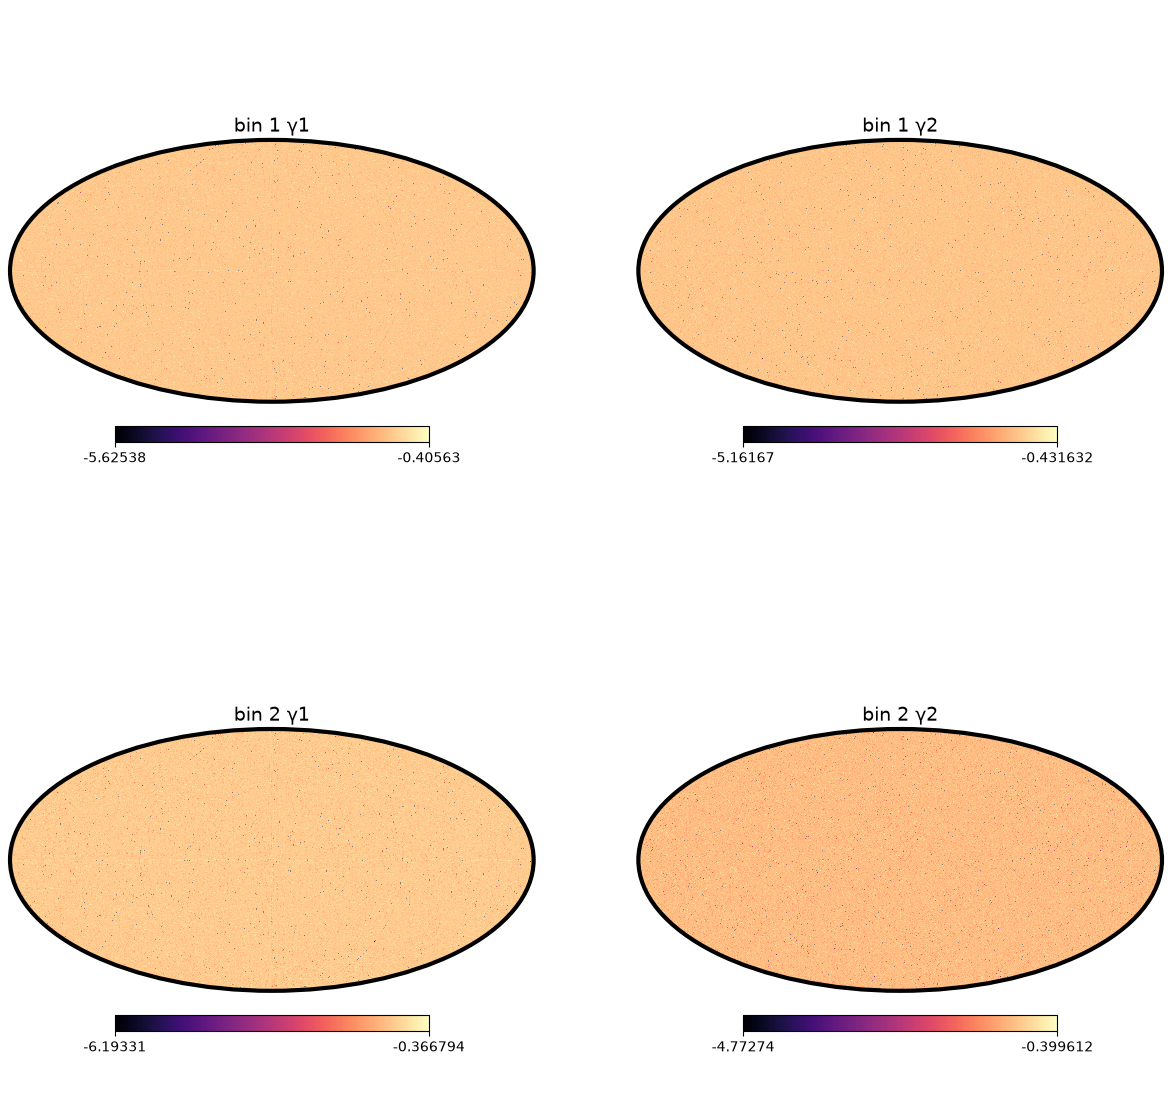

In [8]:
# Put the n_bins convergence maps on the mesh `y` axis so each bin's Kaiser-Squires runs on its
# own device(s); get_shear mirrors that layout onto the shear -> P("y", None, "x").
shear = kappa_born.get_shear(debug_sharding=True, method="jax_cuda")
print(f"{type(shear).__name__}  shape={shear.shape}  (bins, [g1,g2], npix)")
print(f"shear sharding : {shear.array.sharding.spec}")
shear.apply_fn(lambda x: jnp.log10(x + 0.1)).show(
    ncols=2, titles=[f"bin {b + 1} γ{c}" for b in range(shear.shape[0]) for c in (1, 2)]
)

### Inspecting the shear sharding

`get_shear` mirrors the convergence layout onto the shear: `P("y", None, "x")` &mdash; bins over `y`
(N), the two spin-2 components replicated, pixels over `x` (M). The `debug_sharding=True` trace above
shows the stages: the convergence is gathered to `P("y", None)` (whole pixels per device), each
device runs Kaiser&ndash;Squires on its own bin(s) inside a `shard_map`, then the result is resharded
to `P("y", None, "x")` &mdash; no cross-device pixel communication.

In [9]:
print(f"Sharding of shear: {shear.array.sharding}")
jax.debug.visualize_array_sharding(shear.array[:, 0])

Sharding of shear: NamedSharding(mesh=Mesh('x': 4, 'y': 2, axis_types=(Auto, Auto)), spec=P('y', None, 'x'), memory_kind=device)


## Ray-tracing (post-Born)

`jfli.raytrace` propagates the full distortion matrix through each lens plane (via **dorian**),
capturing lens-lens coupling that Born misses. It is **not** JAX-compatible. We ask for both the
ray-traced and dorian-Born maps and compare to the difference (the dorian logs are voluminous, so
we silence them).

In [10]:
logging.getLogger().setLevel(logging.ERROR)
kappa_rt, kappa_born_dorian = jfli.raytrace(cosmo, lightcone, nz_shear=nz_sources, born=True, raytrace=True)

[INFO] raytrace_from_density: z_source=[np.float64(0.01), np.float64(0.0565625), np.float64(0.103125), np.float64(0.1496875), np.float64(0.19625), np.float64(0.24281250000000001), np.float64(0.289375), np.float64(0.3359375), np.float64(0.3825), np.float64(0.4290625), np.float64(0.475625), np.float64(0.5221875), np.float64(0.56875), np.float64(0.6153125), np.float64(0.661875), np.float64(0.7084375), np.float64(0.755), np.float64(0.8015625), np.float64(0.848125), np.float64(0.8946875), np.float64(0.94125), np.float64(0.9878125), np.float64(1.034375), np.float64(1.0809375), np.float64(1.1275), np.float64(1.1740625), np.float64(1.220625), np.float64(1.2671875), np.float64(1.31375), np.float64(1.3603125), np.float64(1.406875), np.float64(1.4534375), np.float64(1.5)], interp='bilinear', nside=512, multi=True
[INFO] Preparing 8 density shells: nside=512, particle mass=4.9932e+04 [10^10 M_sun/h]
[INFO]   Shell 1/8: z=0.0331, d=98.4 Mpc/h
[INFO]   Shell 2/8: z=0.1044, d=305.2 Mpc/h
[INFO]   She

[INFO] Shell 1/1: z=0.0331, d=98.4 Mpc/h


[INFO]   Shell 1/1 done in 7.37s
✔ Ray-tracing complete: 1 shells in 7.46s
[INFO] Ray-tracing: nside=512, z_source=0.103125, interp='bilinear', 1/8 shells contributing
[INFO] Shell 1/1: z=0.0331, d=98.4 Mpc/h


[INFO]   Shell 1/1 done in 7.33s
✔ Ray-tracing complete: 1 shells in 7.41s
[INFO] Ray-tracing: nside=512, z_source=0.1496875, interp='bilinear', 2/8 shells contributing
[INFO] Shell 1/2: z=0.0331, d=98.4 Mpc/h


[INFO]   Shell 1/2 done in 7.33s
[INFO] Shell 2/2: z=0.1044, d=305.2 Mpc/h


...

[INFO]   Shell 4/8 done in 7.24s
[INFO] Shell 5/8: z=0.3929, d=1065.4 Mpc/h


[INFO]   Shell 5/8 done in 7.22s
[INFO] Shell 6/8: z=0.5257, d=1374.9 Mpc/h


[INFO]   Shell 6/8 done in 7.23s
[INFO] Shell 7/8: z=0.6865, d=1717.9 Mpc/h


[INFO]   Shell 7/8 done in 7.25s
[INFO] Shell 8/8: z=0.8852, d=2097.9 Mpc/h


[INFO]   Shell 8/8 done in 7.23s
✔ Ray-tracing complete: 8 shells in 58.04s
✔ raytrace_from_density complete: 33 sources (sequential)


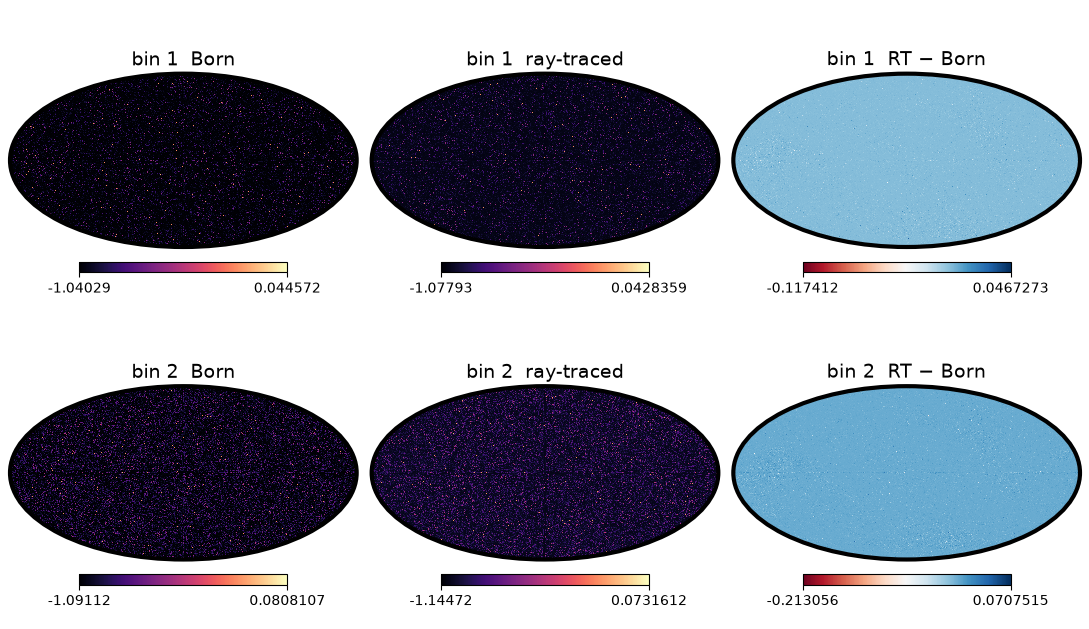

In [11]:
n = kappa_born.shape[0]
fig, axs = plt.subplots(n, 3, figsize=(11, 3.2 * n))
kappa_born.apply_fn(lambda x: jnp.log10(x + 0.1)).plot(ax=axs[:, 0], titles=[f"bin {i + 1}  Born" for i in range(n)])
kappa_rt.apply_fn(lambda x: jnp.log10(x + 0.1)).plot(
    ax=axs[:, 1], titles=[f"bin {i + 1}  ray-traced" for i in range(n)]
)
(kappa_rt - kappa_born_dorian).plot(ax=axs[:, 2], titles=[f"bin {i + 1}  RT $-$ Born" for i in range(n)], cmap="RdBu")
plt.tight_layout()
plt.show()

## Convergence power spectra vs theory

Compare the measured $C_\ell^{\kappa\kappa}$ against the `weak_lensing` Halofit prediction.

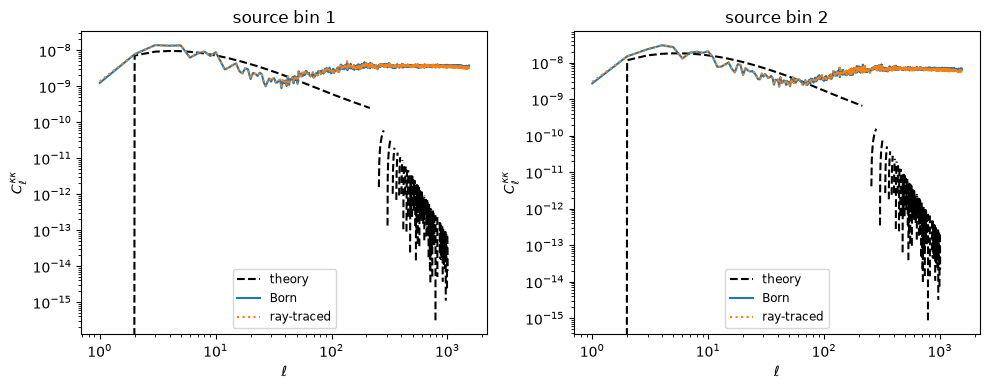

In [12]:
LMAX = 2 * nside
ells = jnp.arange(LMAX)
theory_cl = jfli.compute_theory_cl(
    cosmo, ell=ells, z_source=nz_sources, probe_type="weak_lensing", nonlinear_fn=jc.power.halofit, cross=False
)
cl_born = kappa_born.angular_cl(method="healpy")
cl_rt = kappa_rt.angular_cl(method="healpy")

th = np.asarray(theory_cl.array)
cb = np.asarray(cl_born.array)
cr = np.asarray(cl_rt.array)
L = np.arange(1, cb.shape[-1])
fig, axes = plt.subplots(1, n, figsize=(5 * n, 4))
for i in range(n):
    axes[i].loglog(np.arange(LMAX)[1:], th[i, 1:], "k--", label="theory")
    axes[i].loglog(L, cb[i, 1:], color="C0", label="Born")
    axes[i].loglog(L, cr[i, 1:], color="C1", ls=":", label="ray-traced")
    axes[i].set_title(f"source bin {i + 1}")
    axes[i].set_xlabel(r"$\ell$")
    axes[i].set_ylabel(r"$C_\ell^{\kappa\kappa}$")
    axes[i].legend(fontsize="small")
plt.tight_layout()
plt.show()

## Saving convergence and shear catalogs

Both the convergence and the shear are ordinary fields, so they serialise with `jfli.io.Catalog`
just like the density maps in [notebook 1](../1-introduction-and-basics/01-basics.ipynb).

In [13]:
kappa_cat = jfli.io.Catalog(field=kappa_born, cosmology=cosmo)
kappa_cat.to_parquet("lensing_kappa.parquet")
shear_cat = jfli.io.Catalog(field=shear, cosmology=cosmo)
shear_cat.to_parquet("lensing_shear.parquet")

kappa_reloaded = jfli.io.Catalog.from_parquet("lensing_kappa.parquet")
shear_reloaded = jfli.io.Catalog.from_parquet("lensing_shear.parquet")
print("convergence ->", type(kappa_reloaded.field[0]).__name__, kappa_reloaded.field[0].shape)
print("shear       ->", type(shear_reloaded.field[0]).__name__, shear_reloaded.field[0].shape)

Creating parquet from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

Creating parquet from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating train split: 0 examples [00:00, ? examples/s]

convergence -> SphericalKappaField (2, 3145728)
shear       -> SphericalShearField (2, 2, 3145728)


## Next

[10 &middot; External Catalogs](10-External-Catalog.ipynb) loads convergence/density maps produced
by other codes (CosmoGrid, GowerStreet) into the same `Catalog` containers.